In [1]:
# =============================================================================
# NEURAL FEATURE EXTRACTION CONFIGURATION
# =============================================================================

# Basic trial and timing parameters
TRIAL_NUMBER = 1  # Trial to analyze (changed from 12 - has real movement data)
TIME_BIN_SIZE = 0.02  # seconds (20 ms bins for feature extraction)
SAMPLING_RATE = 30000  # Hz (neural data sampling rate)

# Display options
SHOW_N_CHANNELS = 21  # Number of channels to display in plots
FIGURE_SIZE = (15, 10)  # Figure size for plots

# Spike channels (manually identified)
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

print("✅ Configuration loaded successfully!")
print(f"   • Trial: {TRIAL_NUMBER}")
print(f"   • Time bin size: {TIME_BIN_SIZE*1000:.0f} ms")
print(f"   • Channels: {len(SPIKE_CHANNELS)} spike channels")


✅ Configuration loaded successfully!
   • Trial: 1
   • Time bin size: 20 ms
   • Channels: 21 spike channels


In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neural_feature_extraction import NeuralFeatureExtractor, find_h5_file
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Setup complete!")


✅ Setup complete!


In [3]:
# Diagnostic: Check data structure
def diagnose_trial_data(trial_number=TRIAL_NUMBER):
    """Diagnose trial data structure and behavioral data availability."""
    print(f"🔍 DIAGNOSING TRIAL {trial_number} DATA STRUCTURE")
    print("=" * 50)
    
    # Find H5 file
    h5_file = find_h5_file()
    if h5_file is None:
        print("❌ No H5 files found!")
        return None
    
    print(f"📁 Using H5 file: {h5_file}")
    
    # Initialize extractor
    extractor = NeuralFeatureExtractor(sampling_rate=SAMPLING_RATE)
    
    # Load trial data
    print(f"\n🔍 Loading trial {trial_number}...")
    trial_data = extractor.load_trial_data(h5_file, trial_number)
    
    print(f"\n📊 TRIAL DATA STRUCTURE:")
    print(f"   Available keys: {list(trial_data.keys())}")
    
    for key, value in trial_data.items():
        if isinstance(value, np.ndarray):
            print(f"   {key}: {value.shape} array")
            if key in ['velocity_x', 'velocity_y']:
                non_zero = np.count_nonzero(value)
                print(f"      Non-zero values: {non_zero}/{len(value)}")
                if non_zero > 0:
                    print(f"      Range: {np.min(value):.3f} to {np.max(value):.3f}")
        elif value is None:
            print(f"   {key}: None (missing)")
        else:
            print(f"   {key}: {type(value)} - {value}")
    
    return trial_data

# Run diagnostic
trial_data = diagnose_trial_data()
if trial_data:
    print("\n✅ Diagnostic complete!")
else:
    print("\n❌ Diagnostic failed!")


🔍 DIAGNOSING TRIAL 1 DATA STRUCTURE
📁 Using H5 file: D:\Data\ScienceCorp\trials_aligned.h5

🔍 Loading trial 1...

📊 TRIAL DATA STRUCTURE:
   Available keys: ['neural_data', 'trial_number', 'velocity_x', 'velocity_y', 'behavioral_timestamps', 'duration', 'end_seconds', 'end_time', 'outcome', 'start_seconds', 'start_time', 'target_index']
   neural_data: (96, 1090964) array
   trial_number: <class 'numpy.int32'> - 1
   velocity_x: (1407,) array
      Non-zero values: 125/1407
      Range: -0.496 to 0.724
   velocity_y: (1407,) array
      Non-zero values: 125/1407
      Range: -0.945 to 0.941
   behavioral_timestamps: (1407,) array
   duration: <class 'numpy.float64'> - 36.165474
   end_seconds: <class 'numpy.float64'> - 66.165475
   end_time: <class 'str'> - 2025-03-25T21:23:04.337080002+00:00
   outcome: <class 'str'> - lose
   start_seconds: <class 'numpy.float64'> - 30.0
   start_time: <class 'str'> - 2025-03-25T21:22:28.171605110+00:00
   target_index: <class 'numpy.int64'> - 4

✅ D

🎨 Creating synchronized visualization for trial 1...


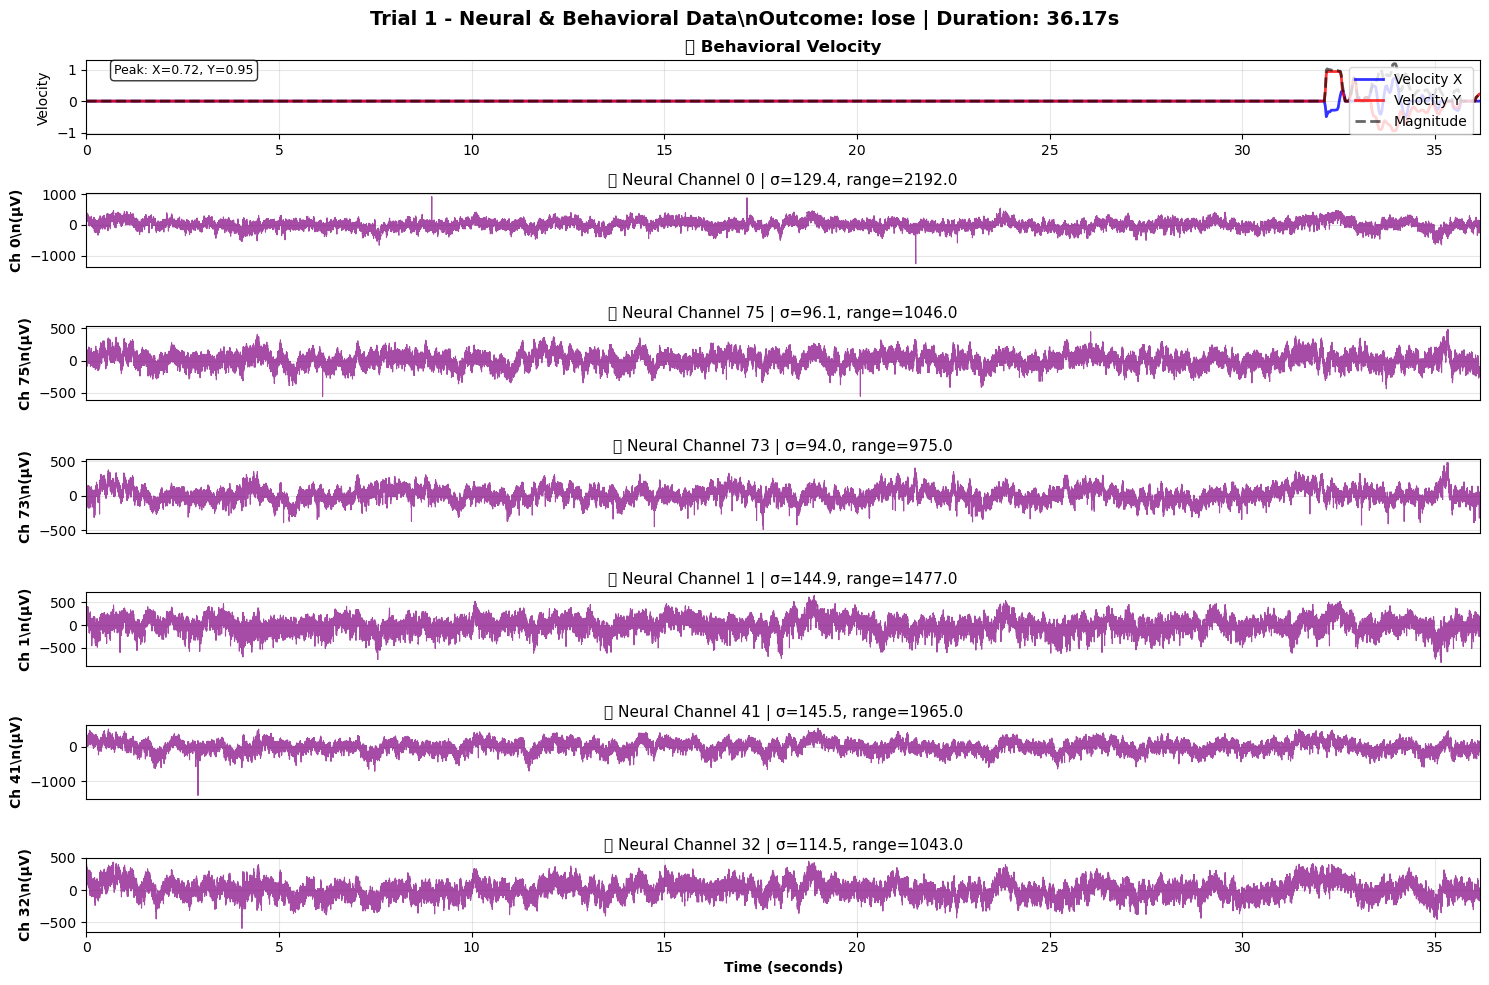

\n📊 Trial 1 Summary:
   Neural data: 96 channels, 1090964 samples
   Behavioral data: 1407 samples
   Velocity peaks: X=0.724, Y=0.945


In [4]:
# Synchronized Neural and Behavioral Visualization
def plot_neural_behavioral_sync(trial_data, figsize=(15, 10)):
    """Create synchronized visualization of neural and behavioral data."""
    print(f"🎨 Creating synchronized visualization for trial {TRIAL_NUMBER}...")
    
    # Get data
    neural_data = trial_data['neural_data']
    velocity_x = trial_data.get('velocity_x', None)
    velocity_y = trial_data.get('velocity_y', None)
    behavioral_timestamps = trial_data.get('behavioral_timestamps', None)
    duration = trial_data.get('duration', neural_data.shape[1] / SAMPLING_RATE)
    
    # Check behavioral data availability
    has_behavioral = (velocity_x is not None and velocity_y is not None)
    
    if not has_behavioral:
        print("⚠️  No behavioral data found - showing neural data only")
        velocity_x = np.zeros(100)
        velocity_y = np.zeros(100)
        behavioral_timestamps = None
    
    # Create time axes
    neural_time = np.linspace(0, duration, neural_data.shape[1])
    
    if behavioral_timestamps is not None and len(behavioral_timestamps) > 0:
        behavioral_time = behavioral_timestamps - behavioral_timestamps[0]
    else:
        behavioral_time = np.linspace(0, duration, len(velocity_x))
    
    # Select channels for visualization
    np.random.seed(42)
    n_channels_to_plot = min(6, len(SPIKE_CHANNELS))
    selected_channels = np.random.choice(len(SPIKE_CHANNELS), n_channels_to_plot, replace=False)
    
    # Create figure
    fig, axes = plt.subplots(n_channels_to_plot + 1, 1, figsize=figsize)
    fig.suptitle(f'Trial {TRIAL_NUMBER} - Neural & Behavioral Data\\n' +
                f'Outcome: {trial_data.get("outcome", "Unknown")} | ' +
                f'Duration: {duration:.2f}s', fontsize=14, fontweight='bold')
    
    # Plot behavioral data (top subplot)
    ax_behavior = axes[0]
    
    if has_behavioral:
        ax_behavior.plot(behavioral_time, velocity_x, 'b-', linewidth=2, label='Velocity X', alpha=0.8)
        ax_behavior.plot(behavioral_time, velocity_y, 'r-', linewidth=2, label='Velocity Y', alpha=0.8)
        
        # Plot velocity magnitude
        velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
        ax_behavior.plot(behavioral_time, velocity_magnitude, 'k--', linewidth=2, 
                        label='Magnitude', alpha=0.6)
        
        ax_behavior.set_title('🕹️ Behavioral Velocity', fontweight='bold')
        ax_behavior.legend(loc='upper right')
        
        # Add statistics
        vel_stats = f'Peak: X={np.max(np.abs(velocity_x)):.2f}, Y={np.max(np.abs(velocity_y)):.2f}'
        ax_behavior.text(0.02, 0.95, vel_stats, transform=ax_behavior.transAxes, 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                        fontsize=9, verticalalignment='top')
    else:
        ax_behavior.text(0.5, 0.5, 'No Behavioral Data Available', 
                        transform=ax_behavior.transAxes, ha='center', va='center',
                        fontsize=14, alpha=0.7)
        ax_behavior.set_title('⚠️ No Behavioral Data', fontweight='bold')
    
    ax_behavior.set_ylabel('Velocity')
    ax_behavior.grid(True, alpha=0.3)
    ax_behavior.set_xlim(0, duration)
    
    # Plot neural data (remaining subplots)
    for i, ch_idx in enumerate(selected_channels):
        ax = axes[i + 1]
        ch_num = SPIKE_CHANNELS[ch_idx]
        
        # Get neural signal
        neural_signal = neural_data[ch_num, :]
        
        # Plot neural signal
        ax.plot(neural_time, neural_signal, 'purple', linewidth=0.8, alpha=0.7)
        
        # Add statistics
        signal_std = np.std(neural_signal)
        signal_range = np.ptp(neural_signal)
        
        ax.set_ylabel(f'Ch {ch_num}\\n(μV)', fontweight='bold', fontsize=10)
        ax.set_title(f'🧠 Neural Channel {ch_num} | σ={signal_std:.1f}, range={signal_range:.1f}', 
                    fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, duration)
        
        # Only show x-axis label on bottom subplot
        if i == len(selected_channels) - 1:
            ax.set_xlabel('Time (seconds)', fontweight='bold')
        else:
            ax.set_xticks([])
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\\n📊 Trial {TRIAL_NUMBER} Summary:")
    print(f"   Neural data: {neural_data.shape[0]} channels, {neural_data.shape[1]} samples")
    
    if has_behavioral:
        print(f"   Behavioral data: {len(velocity_x)} samples")
        print(f"   Velocity peaks: X={np.max(np.abs(velocity_x)):.3f}, Y={np.max(np.abs(velocity_y)):.3f}")
    else:
        print(f"   Behavioral data: Not available")

# Create the visualization
if trial_data is not None:
    plot_neural_behavioral_sync(trial_data)
